# Edge Bearing Fault Detection with SSM on Pico

This notebook demonstrates the complete **bearing fault detection pipeline** using a Temporal Neural Network (TENN) with State Space Model (SSM) layers, deployed on the
**Pico** FPGA platform for real-time edge inference.

## Pipeline

| Stage | What happens | Model type |
|-------|-------------|------------|
| **1. Load data** | ~1-second (41984-sample) vibration segments from UORED-VAFCLS at 42 kHz | — |
| **2. Create model** | Instantiate TENN SSM (kernelized), load trained weights | Keras (full-sequence) |
| **3. Stateful conversion** | Convert to chunk-by-chunk streaming model | Keras (stateful) |
| **4. Quantization** | INT8 weights and activations, INT16 input | Keras (quantized stateful) |
| **5. Akida conversion** | Convert to native Akida format and map to Pico | Akida |
| **6. Hardware metrics** | Latency, FPS, power at 42 kHz sensor rate | — |
| **7. Evaluate** | Compare float vs Akida (AUROC, per-label accuracy) | — |
| **8. Streaming demo** | Simulate real-time inference on a continuous vibration stream | — |
| **9. Decision latency** | Accuracy vs. accumulated chunks — choosing a prediction window | — |

## Glossary

| Term | Value | Meaning |
|------|-------|--------|
| Sample rate | 42 000 Hz | UORED-VAFCLS accelerometer rate |
| Model window | 8192 samples (~195 ms) | Kernelized model's training input |
| Benchmark segment | 41984 samples (~1 s) | Decision window at eval — 164 chunks |
| Timestep | 256 samples (~6.1 ms) | Chunk size for streaming (stateful model) |
| Labels | 4 (inner, outer, ball, cage) | Multi-label — faults are independent |
| Test set | 240 ~1-second segments (8 held-out bearings) | Bearing-wise split — no data leakage |

> **Note:** Cells that convert to Akida, measure hardware metrics, or run on-device inference
> require a free **Pico** device.

## Overview

**What this notebook does:** it takes a pre-trained bearing-fault model all the way to on-device
inference — load a held-out test set → build the model and load weights → convert it to a
**stateful** streaming form → **quantize** to int8/int16 → **convert to Akida and map** it onto the
Pico FPGA → measure hardware latency, throughput, and power → evaluate accuracy on hardware → run a
continuous streaming demo → characterize the accuracy-vs-latency trade-off.

**What Pico is:** Akida Pico is BrainChip's ultra-low-power, event-based neural processing IP for
always-on sensing. It is **sensor-agnostic** — the same neural engine and TENNs (Temporal
Event-based Neural Network) runtime that does keyword spotting from audio processes any 1D stream,
including **vibration**. It runs quantized models directly on raw sensor data — **no DSP, no FFT, no
spectrogram** — by advancing through the signal one sample at a time and carrying a compact internal state (the
SSM hidden state), so SRAM and compute stay constant no matter how long the stream
runs. The reference platform benchmarked here is the Pico FPGA at 50 MHz.

**Why bearing fault detection fits Pico:** vibration monitoring is a continuous, sequential
1D-sensor task — one of Pico's target applications (vibration analysis / predictive maintenance).
Paired with an ultra-low-power MCU, Pico sits **always-on at the sensor** in the µW range while the
host SoC stays in deep sleep; it streams vibration frame-by-frame and raises a single wake event
only when a fault is detected. That is the value: catch a developing bearing fault **on-device, in
real time, without cloud connectivity** and without a power-hungry preprocessing pipeline — reducing
unplanned downtime. It is the same streaming-SSM approach BrainChip uses for keyword spotting,
applied to vibration.

**What you'll get:** an Akida model mapped to Pico that reproduces the reference accuracy
(macro-AUROC ≈ 0.94 on held-out bearings), measured hardware latency / throughput / power, and
guidance on choosing a decision window for your latency budget.

## 1. Imports

In [1]:
import os
os.environ["TF_CPP_MIN_LOG_LEVEL"] = "3"
os.environ["TF_ENABLE_ONEDNN_OPTS"] = "0"

import warnings
warnings.filterwarnings('ignore')

import tensorflow as tf
# zoh_discretize uses @tf.function which fails to JIT-compile on some GPU configs
tf.config.optimizer.set_jit(False)

import numpy as np
import matplotlib.pyplot as plt
import tf_keras
import quantizeml
import cnn2snn
import akida

import akida_models
from akida_models.tenn_recurrent.convert_recurrent import convert_to_stateful
from fd_utils import (
    run_streaming_inference, segment_predictions,
    evaluate_stateful_multilabel, print_metrics_report, print_param_summary,
    plot_healthy_vs_faulty, plot_label_distribution,
    plot_streaming_demo, plot_streaming_debug,
    plot_evaluation_comparison, plot_per_fault_auroc,
    plot_power_estimates, plot_duty_cycle_explanation,
    plot_latency_vs_clock, plot_throughput_vs_clock,
    sigmoid, sliding_mean,
    FAULT_NAMES, SAMPLE_RATE,
)

print(f"TensorFlow  : {tf.__version__}")
print(f"QuantizeML  : {quantizeml.__version__}")
print(f"CNN2SNN     : {cnn2snn.__version__}")
print(f"Akida       : {akida.__version__}")

E0000 00:00:1784792232.448470  803949 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1784792232.452036  803949 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1784792232.460837  803949 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1784792232.460849  803949 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1784792232.460851  803949 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1784792232.460851  803949 computation_placer.cc:177] computation placer already registered. Please check linka

TensorFlow  : 2.19.1
QuantizeML  : 1.2.2
CNN2SNN     : 2.19.2
Akida       : 2.19.2


## 2. Load test data

The **UORED-VAFCLS** dataset contains vibration recordings from 20 bearings at 42 kHz.
Each bearing has three health states: healthy, fault_1, and fault_2. Faults are
multi-label — a bearing can have more than one fault type simultaneously.

The test set is held out by a **bearing-wise split**: **8 bearings (2 per fault type),
240 ~1-second segments**, none of which appear in training. We split by *bearing* rather than
by random segments on purpose — it measures whether the model generalizes to a **previously
unseen bearing**, which is the real deployment scenario (a new bearing installed in the field),
not merely to new time windows of bearings it has already learned. A random segment split would
leak bearing-specific signatures into both train and test and inflate the reported accuracy.

The segments are the same int16 accelerometer data Pico streams in 256-sample chunks, just
stored as whole ~1-second windows for benchmarking. Expect `X_test` of shape `(240, 41984, 1)`
int16 and `y_test` of shape `(240, 4)`, and printed counts showing the 8 held-out bearings with
balanced fault types plus healthy segments.

In [2]:
BASE_DIR     = os.getcwd()
MODEL_LENGTH = 8192   # kernelized model's training window (~195 ms at 42 kHz)
TIMESTEP     = 256    # streaming chunk size (~6.1 ms)
LENGTH       = (42000 // TIMESTEP) * TIMESTEP   # 41984 = ~1 s benchmark decision window

X_test = np.load(os.path.join(BASE_DIR, 'test_data', 'X_test.npy'))
y_test = np.load(os.path.join(BASE_DIR, 'test_data', 'y_test.npy'))

print(f"X_test : {X_test.shape}  dtype={X_test.dtype}")
print(f"y_test : {y_test.shape}  dtype={y_test.dtype}")
print(f"\nFault label counts:")
for i, name in enumerate(FAULT_NAMES):
    print(f"  {name:10s}: {int(y_test[:, i].sum()):4d} / {len(y_test)} segments")
n_healthy = int((y_test.sum(axis=1) == 0).sum())
print(f"  {'healthy':10s}: {n_healthy:4d} / {len(y_test)} segments")

X_test : (240, 41984, 1)  dtype=int16
y_test : (240, 4)  dtype=float32

Fault label counts:
  inner     :   40 / 240 segments
  outer     :   40 / 240 segments
  ball      :   40 / 240 segments
  cage      :   40 / 240 segments
  healthy   :   80 / 240 segments


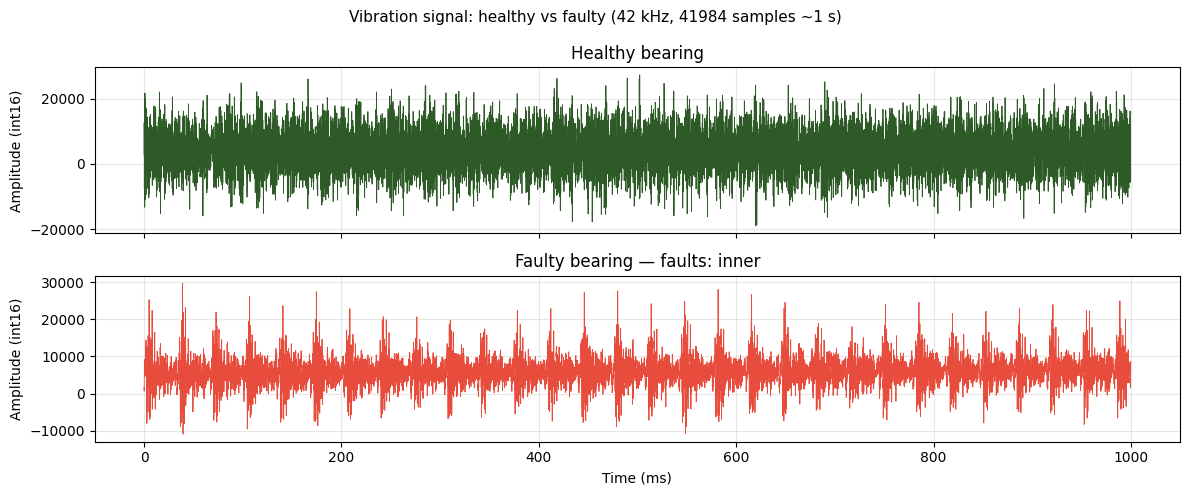

In [3]:
# Visualize a healthy segment vs a faulty segment to see the difference in vibration signature.
plot_healthy_vs_faulty(X_test, y_test, length=LENGTH, sample_rate=SAMPLE_RATE)

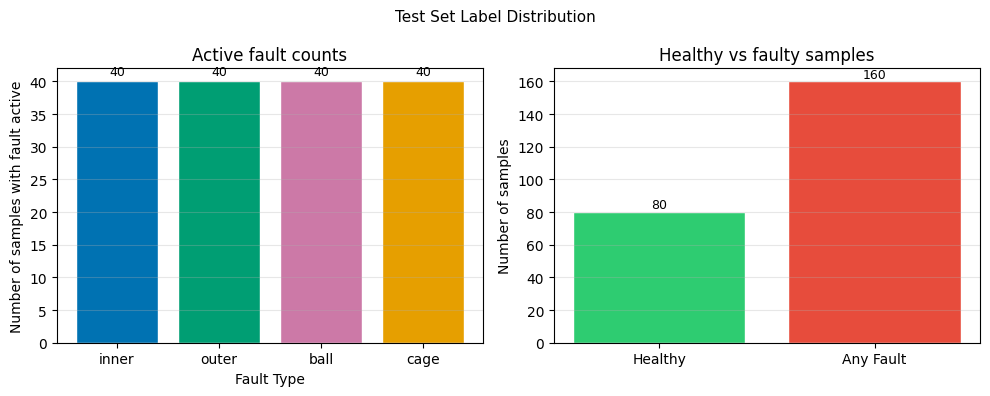

In [4]:
plot_label_distribution(y_test, title="Test Set Label Distribution")

## 3. Create model and load weights

The **TENN recurrent** model uses State Space Model (SSM) layers — linear recurrences whose
weight matrices encode temporal dynamics. Five SSM encoder blocks progressively downsample the
8192-sample input, producing a compact representation for multi-label fault classification.

SSM layers are **kernelizable**: during training the recurrence can be unrolled as a convolution
(fast batch training), then converted to a true recurrent form for streaming inference on Pico
(low latency, stateful, processes one 256-sample chunk per call).

**State Space Model, in short:** an SSM keeps a hidden state that evolves as it reads the sequence;
at each step it maps (state, input) → (new state, output). It is naturally *recurrent* and *streaming*
— it can process one chunk, update state, and pass state to the next chunk — which is exactly how the
signal arrives from a sensor. The kernelized form trains efficiently; the recurrent form is what Pico
executes.

The Keras summary below is titled `tenn_recurrent_uored` with input `(…, 8192, 1)`, five SSM encoder
blocks, and ~17 K parameters.

In [5]:
# Build the kernelized (full-sequence) model and load the trained weights.
model = akida_models.tenn_recurrent_uored(input_shape=(MODEL_LENGTH, 1), num_classes=4)
model.load_weights(os.path.join(BASE_DIR, 'weights', 'tenn_recurrent_uored.h5'))
model.summary()

Model: "tenn_recurrent_uored"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 input (InputLayer)          [(None, 8192, 1)]         0         
                                                                 
 rescaling (Rescaling)       (None, 8192, 1)           0         
                                                                 
 ssm_layer_0 (Kernelized)    (None, 8192, 8)           768       
                                                                 
 ssm_layer_0/downsampling (  (None, 2048, 8)           0         
 Stride)                                                         
                                                                 
 ssm_layer_0/BN (BatchNorma  (None, 2048, 8)           32        
 lization)                                                       
                                                                 
 ssm_layer_0/relu (ReLU)     (None, 2048, 8)  

## 4. Stateful conversion for streaming

For real-time streaming on Pico, we convert the kernelized model to a **stateful recurrent** model:

- **Before:** input `(batch, 8192, 1)` — the kernelized model consumes a whole 8192-sample window at once.
- **After:** input `(1, 256, 1)` — the stateful model advances through the stream **one sample at a time** on the device, carrying its SSM state forward.

The model processes one sample at a time but we pass data to `forward()` in **256-sample chunks** because the network **downsamples time by 256×** (256 input samples produce one output), so 256 samples is the smallest input that yields a complete output step — about one decision every 6.1 ms.

Each `Kernelized` layer becomes a `StatefulProjection → StatefulRecurrent → ExtractToken → StatefulProjection`
block with discretized SSM weights (zero-order-hold). This is exactly the form the device runs: it never buffers a whole segment, so **SRAM and compute stay
constant regardless of how long the stream runs**.

The summary below shows the layers are now `StatefulProjection` / `StatefulRecurrent` blocks, with
input `(1, 256, 1)` and output `(1, 1, 4)`.

In [6]:
# zoh_discretize inside convert_to_stateful uses @tf.function; force CPU execution to
# avoid a GPU libdevice / JIT compilation failure seen on some configs.
with tf.device('/cpu:0'):
    model_stateful = convert_to_stateful(model, timesteps=TIMESTEP)
model_stateful.summary()

Model: "tenn_recurrent_uored"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 input (InputLayer)          [(1, 256, 1)]             0         
                                                                 
 rescaling (Rescaling)       (1, 256, 1)               0         
                                                                 
 ssm_layer_0_input_proj (St  (1, 256, 64)              64        
 atefulProjection)                                               
                                                                 
 ssm_layer_0 (StatefulRecur  (1, 256, 64, 2)           128       
 rent)                                                           
                                                                 
 ssm_layer_0_extract_intern  (1, 256, 64)              0         
 al_state_real (ExtractToke                                      
 n)                                           

## 5. Quantization

Quantize the stateful model to **INT8 weights and INT8 activations** with an **INT16 input** (raw
int16 accelerometer samples). Calibration data from the training split is passed through the model so
`quantizeml` can choose per-tensor scale factors that preserve the signal range.

**Why int8 / int16:** the Akida hardware executes integer arithmetic, so the model runs in int8/int16
on the device. Integer weights use about **4× less memory** than float32 and cost less energy per
operation. With scales calibrated on representative data, the accuracy loss is typically negligible
(confirmed in Section 7, where the Akida result matches the float model).

The summary below shows the same architecture with layers now prefixed `Quantized…` and a
`Dequantizer` appended; the cell prints "Quantization complete." with no errors.

In [7]:
from quantizeml.models import QuantizationParams

cal_data = np.load(os.path.join(BASE_DIR, 'calibration', 'uored_calibration.npz'))['data']
print(f"Calibration data: {cal_data.shape}  dtype={cal_data.dtype}")

# INT8 weights + INT8 activations, INT16 input (raw int16 accelerometer samples).
# quantize() calls tf.math.log during QuantizedStatefulRecurrent.build(), which fails
# under GPU JIT on some configs, so we force CPU (same root cause as convert_to_stateful).
qparams = QuantizationParams(activation_bits=8, weight_bits=8, input_dtype='int16')
with tf.device('/cpu:0'):
    model_quantized = quantizeml.models.quantize(
        model_stateful,
        qparams=qparams,
        samples=cal_data,
        batch_size=32,
        epochs=1,
    )
print("Quantization complete.")
model_quantized.summary()

Calibration data: (256, 8192, 1)  dtype=int16
Quantization complete.
Model: "tenn_recurrent_uored"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 input (InputLayer)          [(1, 256, 1)]             0         
                                                                 
 rescaling (QuantizedRescal  (1, 256, 1)               0         
 ing)                                                            
                                                                 
 ssm_layer_0_input_proj (Qu  (1, 256, 64)              64        
 antizedStatefulProjection)                                      
                                                                 
 ssm_layer_0 (QuantizedStat  (1, 256, 64, 2)           130       
 efulRecurrent)                                                  
                                                                 
 ssm_layer_0_extract_intern  (1, 256, 64)  

In [8]:
# Parameters and memory footprint at each pipeline stage.
print_param_summary(model, model_stateful, model_quantized)

Stage                            Parameters   Float (KB)    INT8 (KB)
────────────────────────────────────────────────────────────────────
Kernelized (training)                17,120         66.9            —
Stateful (streaming)                 16,440         64.2            —
Quantized INT8 (stateful)            16,564         64.7         16.2


## 6. Akida conversion and hardware mapping

`cnn2snn.convert()` turns the quantized Keras model into a native **Akida** model; `.map(device)`
compiles each layer for the **Pico** FPGA. This is the step that actually targets the device — after
mapping, `model_akida.forward(...)` runs on the FPGA instead of the CPU.

The mapped summary shows how layers are placed: those that satisfy Akida's hardware constraints run on
the **FPGA (TNP_R)**. For this model the entire network maps to the Pico as a single hardware sequence
— expect the summary to report **1 sequence**, `TNP_R` = 1, input `[1, 256, 1]` and output `[1, 1, 4]`.

In [9]:
model_akida = cnn2snn.convert(model_quantized)

# akida.devices() returns an empty list when no Pico is free (e.g. it is held by
# another process). Guard against it so the failure is explicit, not a bare IndexError.
devices = akida.devices()
if not devices:
    raise RuntimeError(
        "No Akida (Pico) device is available — akida.devices() returned an empty list. "
        "The Pico is likely in use by another process. Check with `akida devices` in a "
        "terminal (or akida.devices() in Python); once a device is free, re-run this cell."
    )
device = devices[0]
model_akida.map(device)

W0000 00:00:1784792268.097498  803949 loop_optimizer.cc:934] Skipping loop optimization for Merge node with control input: tenn_recurrent_uored/ssm_layer_0/assert_less/Assert/AssertGuard/branch_executed/_34


In [10]:
model_akida.summary()

                                     Model Summary                                     
_______________________________________________________________________________________
Input shape  Output shape  Sequences  Layers  NPs  Skip DMAs  External Memory (Bytes)
[1, 256, 1]  [1, 1, 4]     1          7       1    0          0                      
_______________________________________________________________________________________

_________________________
Component (type)  Count
TNP_R             1    
_________________________

____________________________________________________________________________________________________________
Layer (type)                                    Output shape  Kernel shape                      Components

=================== HW/ssm_layer_0_output_proj-dequantizer (Hardware) - size: 20152 bytes ==================

ssm_layer_0_output_proj (StatefulRecurrent)     [1, 64, 8]    (1, 64)  (64,)  (64,)  (64, 8)    1 TNP_R   
____________________________

### Performance: latency, throughput, and the frame deadline

The sensor produces a new 256-sample frame every **256 / 42 000 = 6.1 ms** (the *frame period*). To
monitor in real time without dropping data, the device must finish inferring on one frame before the
next arrives — so per-frame latency must stay **below 6.1 ms** (equivalently, throughput must stay
above **1000 / 6.1 ≈ 164 fps**). That 6.1 ms line is the "frame deadline" drawn on the plots below.

The cell below measures the per-frame inference time from the mapped Akida model (`inference_clk`) and
derives latency and FPS across FPGA clock speeds, plus a rescaled estimate for a 400 MHz Akida clock.

- **What you should see:** at 50 MHz, roughly **1 ms per frame** (~770 fps) — far under the 6.1 ms
  deadline. The latency-vs-clock and throughput-vs-clock plots show this margin holds across the whole
  25–100 MHz range, so the model keeps up in real time at every clock. That spare time is **headroom for power
  savings**: the device finishes a frame in ~1 ms and can sit idle (leakage only) for the remaining
  ~5 ms of every 6.1 ms period — i.e. duty-cycle / power-gate between inferences (and optionally run a
  lower clock). Section "Power and energy" quantifies this.

In [11]:
# FPS and latency for the mapped Akida model on Pico
CHUNK = 256

# Synthetic batch of int16 frames in the shape the Akida model expects: (batch, 1, 256, 1).
# The values are irrelevant here — we are measuring timing, not accuracy.
batch = 1000
frame = np.random.randint(-2048, 2048, size=(batch, 1, CHUNK, 1)).astype(np.int16)

# Warmup
_ = model_akida.forward(frame)
# Measured forward (populates .metrics)
_ = model_akida.forward(frame)

hw_clock = 50_000_000       # 50 MHz (FPGA); change if your board differs
high_clock = 400_000_000    # 400 MHz for scaled numbers

if hasattr(model_akida, 'metrics') and model_akida.metrics is not None:
    m = model_akida.metrics
    try:
        hw_fps = hw_clock / (m['inference_clk'] / batch)
        hw_latency_ms = 1000 / hw_fps
        scaled_fps = high_clock * (hw_clock / (m['inference_clk'] / batch)) / hw_clock
        scaled_latency_ms = hw_clock * (1000 / (hw_clock / (m['inference_clk'] / batch))) / high_clock
        print(f"  HW Clock:       {hw_clock/1e6:.0f} MHz")
        print(f"  HW Mesh Latency: {hw_latency_ms:.4f} ms")
        print(f"  HW Mesh FPS:    {hw_fps:.2f}")
        print(f"  Scaled HW @ 400 MHz - Latency: {scaled_latency_ms:.2f} ms  FPS: {scaled_fps:.2f}")
    except (KeyError, TypeError):
        print("  (no inference_clk metric — requires a mapped Akida device)")
else:
    print("  (no .metrics — requires a mapped Akida device; running in software simulation)")

  HW Clock:       50 MHz
  HW Mesh Latency: 1.2909 ms
  HW Mesh FPS:    774.66
  Scaled HW @ 400 MHz - Latency: 0.16 ms  FPS: 6197.25


### Power and energy

The device is active only for the ~1 ms it takes to process a frame and idles (leakage only) for the
rest of each 6.1 ms period, so the figure that matters for an always-on sensor is the **energy spent
per decision**, not the peak power.

- **Energy per inference ≈ 0.8 µJ**, essentially **constant across clock speed**: a higher clock
  shortens the active burst but raises power proportionally, so the energy per decision is unchanged
  (this is what the duty-cycle plot illustrates).
- **Average power ≈ 130 µW** at the 6.1 ms streaming cadence (active power during the burst, leakage
  in between).

Continuous bearing monitoring therefore costs on the order of **sub-microjoule per decision at ~0.1 mW
average** — a budget an always-on edge node can sustain while the host SoC stays asleep. The table and
plots below break this down across clock speeds. (Power figures are estimates from Pico hardware
characterization; actual values depend on process, voltage, and temperature.)

   Clock    Latency        FPS     Duty-cycle   Active power  E_streaming
   (MHz)       (ms)                power (μW)           (μW)         (μJ)
------------------------------------------------------------------------
      25      2.582      387.3          130.5          289.0        0.795
      30      2.151      464.8          130.5          344.0        0.795
      35      1.844      542.3          130.5          399.0        0.795
      40      1.614      619.7          130.5          454.0        0.795
      45      1.434      697.2          130.5          509.0        0.795
      50      1.291      774.7          130.5          564.0        0.795
      55      1.174      852.1          130.5          619.0        0.795
      60      1.076      929.6          130.5          674.0        0.795
      65      0.993     1007.1          130.5          729.0        0.795
      70      0.922     1084.5          130.5          784.0        0.795
      75      0.861     1162.0         

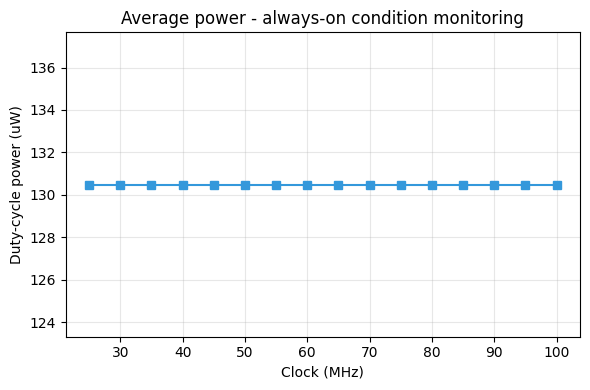

In [12]:
# Power estimates: 25–100 MHz, 5 MHz steps, with duty cycle
# Reference: Pico hardware characterization (22 nm, 50 MHz nominal, 5% switching)
DYNAMIC_50MHZ_UW = 550   # μW at 50 MHz
LEAKAGE_UW = 14          # μW (constant)
BUFFER_MS = 1000 * CHUNK / SAMPLE_RATE  # streaming buffer period: 256 / 42 kHz = 6.1 ms
REF_CLOCK_MHZ = 50       # Reference clock for power scaling

# Inference cycles per frame from the measured Akida metric.
batch = 1000
try:
    inference_clk = m['inference_clk'] / batch
except (NameError, KeyError, TypeError):
    inference_clk = 50_000_000 * 0.0014506
# Clock range: 25–100 MHz, step 5 MHz
clocks_mhz = np.arange(25, 101, 5)
latencies, duty_powers, active_powers, e_streaming = [], [], [], []

print(f"{'Clock':>8} {'Latency':>10} {'FPS':>10} {'Duty-cycle':>14} {'Active power':>14} {'E_streaming':>12}")
print(f"{'(MHz)':>8} {'(ms)':>10} {'':>10} {'power (μW)':>14} {'(μW)':>14} {'(μJ)':>12}")
print("-" * 72)
for f_mhz in clocks_mhz:
    f_hz = f_mhz * 1e6
    scale = f_mhz / REF_CLOCK_MHZ
    dynamic_uw = DYNAMIC_50MHZ_UW * scale
    total_uw = max(dynamic_uw + LEAKAGE_UW, LEAKAGE_UW)
    latency_ms = (inference_clk / f_hz) * 1000
    fps = f_hz / inference_clk
    duty = min(latency_ms / BUFFER_MS, 1.0)
    duty_power_uw = total_uw * duty + LEAKAGE_UW * (1 - duty)
    e_streaming_uj = duty_power_uw * (BUFFER_MS / 1000)
    latencies.append(latency_ms)
    duty_powers.append(duty_power_uw)
    active_powers.append(total_uw)
    e_streaming.append(e_streaming_uj)
    print(f"{f_mhz:>8} {latency_ms:>10.3f} {fps:>10.1f} {duty_power_uw:>14.1f} {total_uw:>14.1f} {e_streaming_uj:>12.3f}")

plot_power_estimates(clocks_mhz, np.array(duty_powers))

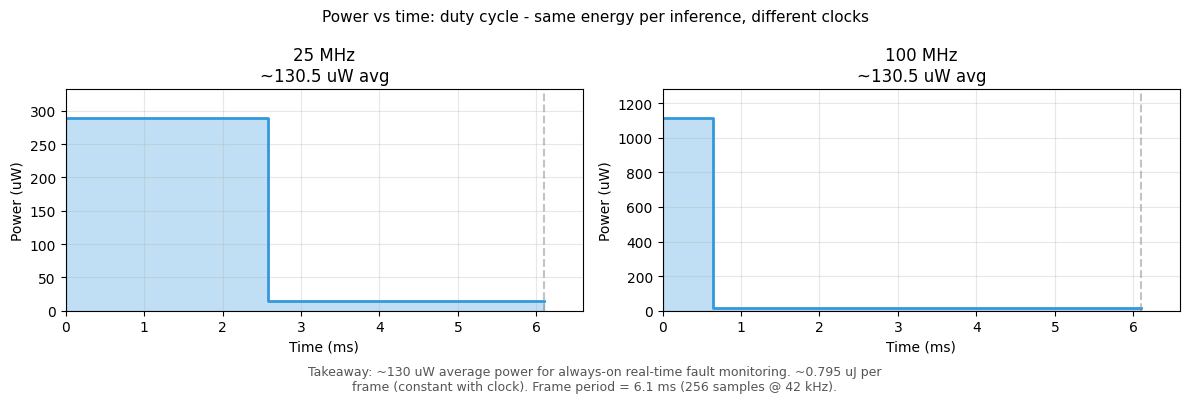

In [13]:
plot_duty_cycle_explanation(inference_clk, buffer_ms=BUFFER_MS)

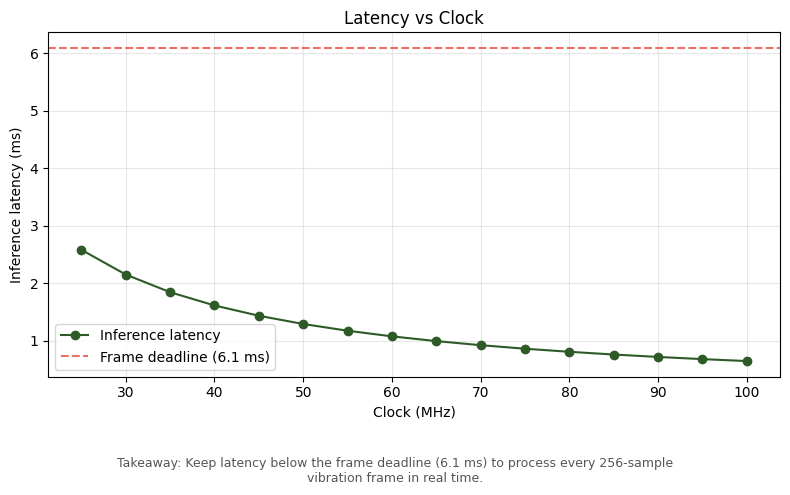

In [14]:
plot_latency_vs_clock(clocks_mhz, np.array(latencies), buffer_ms=BUFFER_MS)

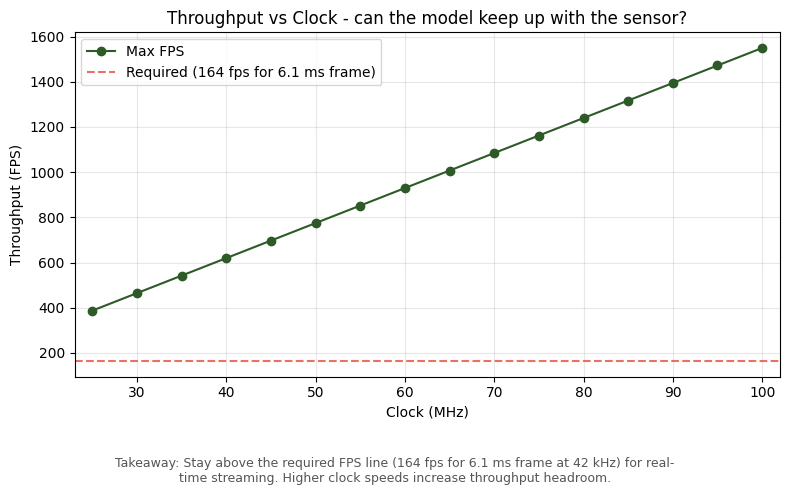

In [15]:
plot_throughput_vs_clock(clocks_mhz, inference_clk, buffer_ms=BUFFER_MS)

## 7. Evaluate on the full test set — float vs Akida

**What this shows:** we run all **240 held-out ~1-second test segments** through both the **float**
model and the **Akida** model on Pico and compare their scores. **Why it matters:** it tells you
whether deploying to Pico — int8 quantization plus mapping to the FPGA — changes the model's accuracy,
the deployment fidelity you'd want to confirm before shipping.

| Metric | What it measures |
|---|---|
| **Macro AUROC** | How well the model separates faulty from healthy for each fault, averaged over the four faults (1.0 = perfect, 0.5 = chance). |
| **Micro AUROC** | The same, pooled across all faults and segments together. |
| **Hamming score** | Per-label accuracy — the fraction of individual fault-label predictions that are correct. |

**What to look for:** the float and Akida bars are msame. Here they match to rounding on AUROC
(0.94) and to within ~1% on per-label accuracy — so running on Pico reproduces the trained model's
behavior, with only the small numeric differences expected from int8.

*Absolute accuracy reflects this reference model and its training data — the goal is deployment
fidelity, not tuning the model, which improves with more/representative data.*

Evaluating Akida model on Pico over 240 segments ...


Evaluating:   0%|          | 0/240 [00:00<?, ?seg/s]

Evaluating: 100%|██████████| 240/240 [00:17<00:00, 13.59seg/s]


Akida (Pico) — Full Test Set

Primary Metrics:
  Macro AUROC:        0.9420
  Micro AUROC:        0.8999
  Hamming Score:      0.8896   (per-label accuracy)

Per-Fault AUROC:
  inner       :    0.9972
  outer       :    0.9924
  ball        :    0.9393
  cage        :    0.8390

Evaluating float stateful model over 240 segments ...


Evaluating: 100%|██████████| 240/240 [05:19<00:00,  1.33s/seg]

Float Stateful — Full Test Set

Primary Metrics:
  Macro AUROC:        0.9420
  Micro AUROC:        0.8979
  Hamming Score:      0.8823   (per-label accuracy)

Per-Fault AUROC:
  inner       :    0.9844
  outer       :    0.9901
  ball        :    0.9595
  cage        :    0.8341


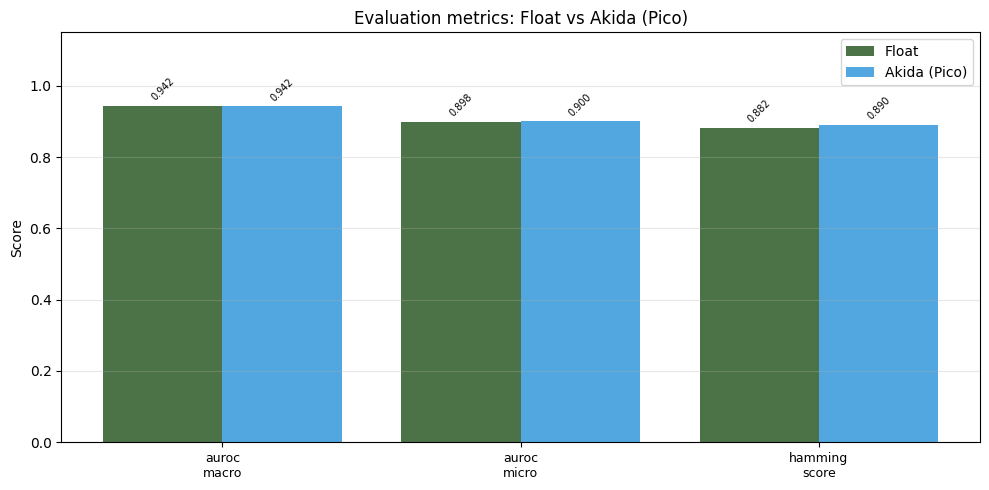

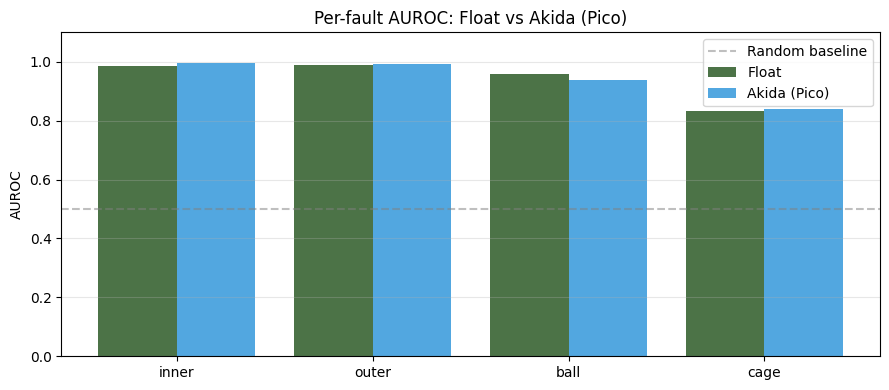

In [16]:
# Evaluate the Akida model on Pico
print(f"Evaluating Akida model on Pico over {len(X_test)} segments ...")
metrics_akida = evaluate_stateful_multilabel(
    model_akida, X_test, y_test,
    length=LENGTH, timestep=TIMESTEP, in_akida=True, verbose=1,
)
print_metrics_report(metrics_akida, title="Akida (Pico) — Full Test Set")

# Evaluate the float stateful model for comparison
print(f"\nEvaluating float stateful model over {len(X_test)} segments ...")
metrics_float = evaluate_stateful_multilabel(
    model_stateful, X_test, y_test,
    length=LENGTH, timestep=TIMESTEP, in_akida=False, verbose=1,
)
print_metrics_report(metrics_float, title="Float Stateful — Full Test Set")

# Visual comparison: metric-by-metric and per-fault AUROC (Float vs Akida)
variants = {"Float": metrics_float, "Akida (Pico)": metrics_akida}
plot_evaluation_comparison(variants, primary_metrics=['auroc_macro', 'auroc_micro', 'hamming_score'])
plot_per_fault_auroc(variants)

## 8. Streaming inference demo

This section shows how the model behaves on a **continuous vibration stream** — the same way it would run on Pico in a real application, not on isolated ~1 s segments.

### What's happening (pipeline)

1. **Build a simulated stream** — We concatenate **10 test segments** (from different bearings and health states) into one long waveform. This mimics a continuous sensor feed running without interruption.

2. **Frame-by-frame inference** — We step through the stream in **256-sample chunks** (the *timestep*). For each chunk we call the model once. The model's **internal state** is carried from one frame to the next, so it effectively "remembers" earlier vibration within the stream.

3. **Raw logits and smoothing** — Each frame yields **4 logits** (one per fault type: inner, outer, ball, cage). We store them as `preds_raw`. A **sliding mean** over time and **sigmoid** give smoother, more stable per-fault probabilities.

4. **One prediction per segment** — To evaluate accuracy, we need one label per original ~1 s segment. For each segment we **average the raw logits** over its 164 frames (`LENGTH // TIMESTEP`), then apply sigmoid and threshold at 0.5 to get `seg_preds`.

5. **Graph representation** — The plot shows the model making **continuous, stateful decisions** as time progresses — exactly how it runs on Pico in real time.

### Why stream continuously?

This demo uses the **same flow** that runs on device: one 256-sample frame at a time, state carried forward, no full-segment buffer needed. Crucially, there is **no state reset between segments** — in deployment the sensor runs continuously and the model sees segment boundaries just like any other chunk of data. That is the true streaming scenario, so predictions can take a few frames to settle after each boundary.

In [17]:
def generate_predictions(model, input, sliding_window=16, apply_sigmoid=True):
    """
    Run streaming inference on a continuous vibration input; returns raw and smoothed predictions.
    This is the core streaming logic: step through the stream in chunks of `timestep` samples,
    run the model on each chunk (state is carried across chunks in stateful models), then
    optionally smooth the logits with a sliding mean and sigmoid.
    """
    in_akida = isinstance(model, akida.Model)
    if not in_akida:
        model_func = tf.function(model)

    timestep = model.input_shape[1]
    n_faults = int(model.output_shape[-1])  # 4 fault types

    preds = np.zeros((0, n_faults))
    if input.ndim == 1:
        input = input[:, np.newaxis]
    if input.shape[0] % timestep != 0:
        pad_length = timestep - (input.shape[0] % timestep)
        input = np.pad(input, ((0, pad_length), (0, 0)), mode='constant', constant_values=0)

    for tt in np.arange(0, input.shape[0], timestep):
        frame = np.expand_dims(input[tt:tt + timestep], 0).astype(np.float32)
        if in_akida:
            outs = model.forward(np.expand_dims(frame, axis=1).astype(np.int16))
        else:
            outs = model_func(tf.convert_to_tensor(frame))
        outs = np.squeeze(np.asarray(outs))
        if outs.ndim == 1:
            outs = outs[np.newaxis, :]
        preds = np.concatenate((preds, outs), axis=0)

    if sliding_window > 0:
        preds_smooth = sliding_mean(preds, window_size=sliding_window)
    else:
        preds_smooth = preds.copy()
    if apply_sigmoid:
        preds_smooth = sigmoid(preds_smooth)

    return preds, preds_smooth

In [18]:
# --- Streaming inference pipeline ---
# Combine N_STREAM_SAMPLES test segments sequentially as one continuous stream
N_STREAM_SAMPLES = 10
SEED = 42  # set to None for a different random order each run
if SEED is not None:
    np.random.seed(SEED)
indices = np.random.permutation(len(X_test))[:N_STREAM_SAMPLES]
stream = np.concatenate([X_test[i] for i in indices], axis=0)  # (N_STREAM_SAMPLES*LENGTH, 1)
demo_labels = y_test[indices]
print(f"Stream shape: {stream.shape} (={N_STREAM_SAMPLES} x {LENGTH} timepoints)")
print(f"Segment indices (order in stream): {indices}")
print(f"Ground-truth labels for the {N_STREAM_SAMPLES} segments:")
for i, (idx, lbl) in enumerate(zip(indices, demo_labels)):
    active = [FAULT_NAMES[j] for j, v in enumerate(lbl) if v > 0.5]
    print(f"  Segment {i} (X_test[{idx}]): {', '.join(active) if active else 'healthy'}")

# Stream on the Akida model mapped to Pico (state carries across chunks, no reset between segments).
streaming_model = model_akida
if hasattr(streaming_model, 'reset_states'):
    streaming_model.reset_states()
preds_raw, preds_smooth = generate_predictions(
    streaming_model, stream,
    sliding_window=16,
    apply_sigmoid=True,
)

Stream shape: (419840, 1) (=10 x 41984 timepoints)
Segment indices (order in stream): [ 24   6  93 109 104 172 233  86   9 143]
Ground-truth labels for the 10 segments:
  Segment 0 (X_test[24]): inner
  Segment 1 (X_test[6]): healthy
  Segment 2 (X_test[93]): healthy
  Segment 3 (X_test[109]): outer
  Segment 4 (X_test[104]): outer
  Segment 5 (X_test[172]): ball
  Segment 6 (X_test[233]): cage
  Segment 7 (X_test[86]): outer
  Segment 8 (X_test[9]): healthy
  Segment 9 (X_test[143]): ball


In [19]:
# Segment-wise accuracy: each original segment has LENGTH // TIMESTEP = 164 output frames
# Use mean of RAW LOGITS per segment → sigmoid → threshold 0.5
# Not mean of sigmoid probs — logit averaging is more numerically stable
segments_per_sample = LENGTH // TIMESTEP  # 164
seg_probs_list, seg_preds_list = [], []
for i in range(N_STREAM_SAMPLES):
    start = i * segments_per_sample
    end   = (i + 1) * segments_per_sample
    seg_mean_logits = preds_raw[start:end].mean(axis=0)     # average raw logits over 164 frames
    probs = 1 / (1 + np.exp(-seg_mean_logits))              # sigmoid
    seg_probs_list.append(probs)
    seg_preds_list.append((probs >= 0.5).astype(int))
seg_probs = np.stack(seg_probs_list)    # (N_STREAM_SAMPLES, 4)
seg_preds = np.stack(seg_preds_list)    # (N_STREAM_SAMPLES, 4)

exact_match = np.mean(np.all(seg_preds == demo_labels.astype(int), axis=1))
hamming     = np.mean(seg_preds == demo_labels.astype(int))
print(f"Segment predictions:")
for i in range(N_STREAM_SAMPLES):
    true_faults = [FAULT_NAMES[j] for j, v in enumerate(demo_labels[i]) if v > 0.5]
    pred_faults = [FAULT_NAMES[j] for j, v in enumerate(seg_preds[i]) if v]
    match = 'v' if np.all(seg_preds[i] == demo_labels[i].astype(int)) else 'x'
    print(f"  [{match}] Seg {i}: true={true_faults or ['healthy']}  pred={pred_faults or ['healthy']}")
print(f"\nStreaming accuracy (over {N_STREAM_SAMPLES} segments, no state reset):")
print(f"  Exact match  : {exact_match:.2%}  ({int(exact_match*N_STREAM_SAMPLES)}/{N_STREAM_SAMPLES} fully correct)")
print(f"  Hamming score: {hamming:.2%}")

Segment predictions:
  [v] Seg 0: true=['inner']  pred=['inner']
  [v] Seg 1: true=['healthy']  pred=['healthy']
  [v] Seg 2: true=['healthy']  pred=['healthy']
  [v] Seg 3: true=['outer']  pred=['outer']
  [v] Seg 4: true=['outer']  pred=['outer']
  [x] Seg 5: true=['ball']  pred=['healthy']
  [x] Seg 6: true=['cage']  pred=['inner']
  [v] Seg 7: true=['outer']  pred=['outer']
  [v] Seg 8: true=['healthy']  pred=['healthy']
  [v] Seg 9: true=['ball']  pred=['ball']

Streaming accuracy (over 10 segments, no state reset):
  Exact match  : 80.00%  (8/10 fully correct)
  Hamming score: 92.50%


### Understanding the graph

The plot has **three panels**:

- **Top — "Vibration stream"** — The **waveform** of the concatenated stream (amplitude vs time in ms). **Dashed vertical lines** mark boundaries between segments.

- **Middle — "Per-fault probability"** — A **heatmap** where each row is a fault type (inner, outer, ball, cage) and each column is a frame. Color shows the fault probability (sigmoid of logits): **light = healthy** (low probability), **dark = fault detected** (high probability).

- **Bottom — "Predictions vs ground truth"** — Each column is a segment. **Circles** mark predicted faults; **×** marks predicted healthy; **green border** = correct, **red border** = wrong. **Black squares** mark the true faults in ground truth.

- **How to read it:** In a healthy run the heatmap stays light for healthy segments and turns dark on the correct fault row for faulty segments. The graph shows the model making **continuous, stateful decisions** as time progresses — exactly how it runs on Pico in real time.

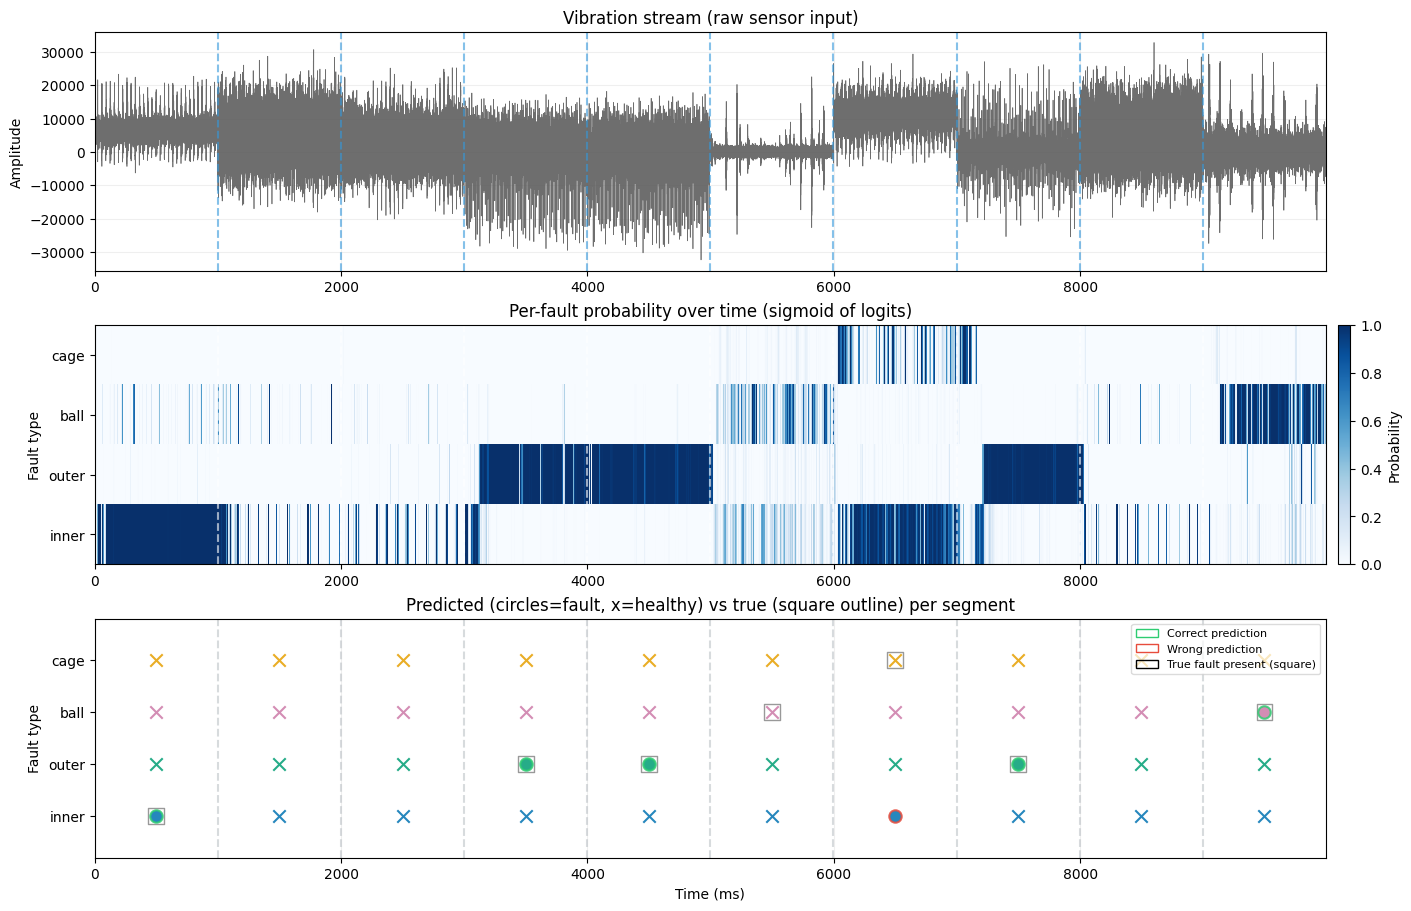

In [20]:
plot_streaming_demo(
    signal=stream,
    preds_raw=preds_raw,
    seg_probs=seg_probs,
    seg_preds=seg_preds,
    true_labels=demo_labels,
    length=LENGTH,
    timestep=TIMESTEP,
    n_segments=N_STREAM_SAMPLES,
)

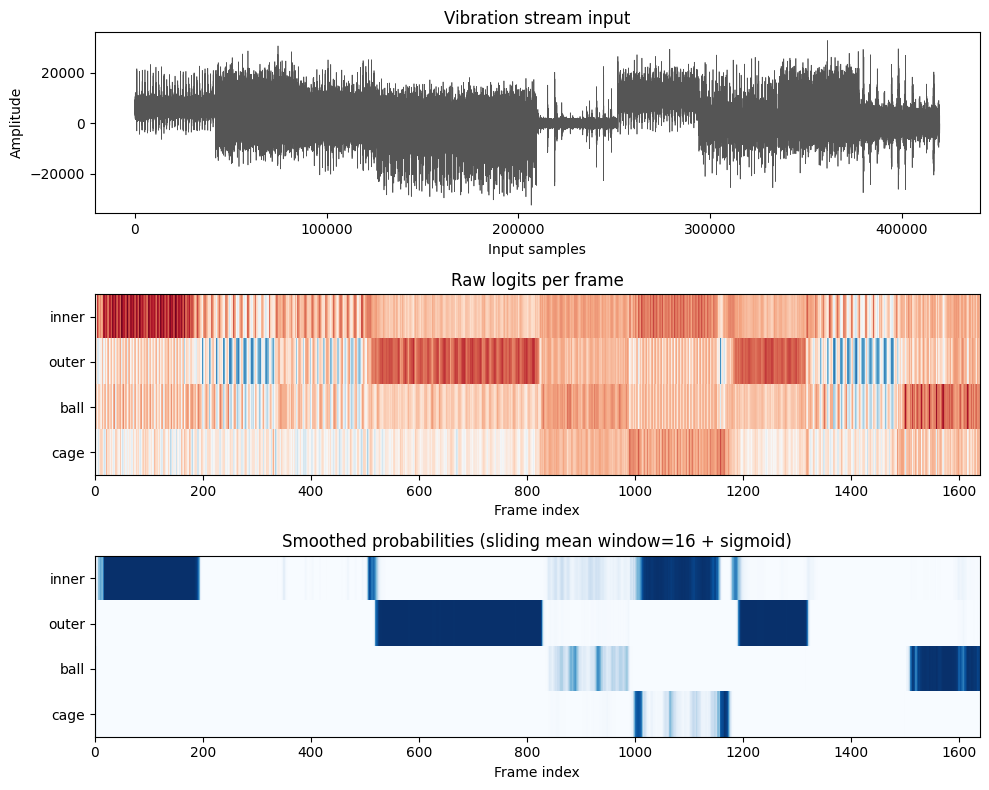

In [21]:
plot_streaming_debug(stream, preds_raw, preds_smooth, sliding_window=16)

## 9. Accuracy vs. decision latency

The stateful model produces one output per 256-sample chunk (6.1 ms at 42 kHz). A class
prediction is formed by averaging the per-chunk logits accumulated so far, then applying a
sigmoid and a 0.5 threshold, so a prediction can be read out after any number of chunks —
not only after a full ~1-second segment. Accumulating more chunks uses more temporal evidence
but increases the time before a decision is available.

The sweep below reports accuracy at a range of accumulation depths on the held-out test set.
Accuracy rises as more chunks are accumulated and levels off once the accumulated window
reaches the model's 8192-sample training window (≈ 32 chunks, ≈ 195 ms); beyond that,
additional accumulation changes accuracy little. Use this curve to choose a decision window
for a target latency; the operating point depends on the model, sampling rate, and fault
types, so measure it on the data for your own deployment.

**Compute cost is unchanged.** The decision window is a **post-processing** choice — it sets how many
per-chunk outputs are averaged, not how much the model computes. Every inference still runs on **one
256-sample chunk** with constant compute and memory; a longer window simply averages more of those
cheap per-chunk outputs over time, and the device never buffers the whole window. This is unlike a
conventional convolutional model, which must ingest the **entire window** (e.g. a full second) as one
input for every prediction, with compute and memory that grow with the window length.

chunks  latency (ms)  macro AUROC   hamming
     1           6.1       0.6944    0.7854
     2          12.2       0.7362    0.7781
     4          24.4       0.8043    0.8042
     8          48.8       0.8943    0.8083
    12          73.1       0.9129    0.8458
    16          97.5       0.9232    0.8531
    24         146.3       0.9313    0.8729
    32         195.0       0.9382    0.8833
    48         292.6       0.9456    0.8885
    64         390.1       0.9453    0.8885
    96         585.1       0.9455    0.8885
   128         780.2       0.9428    0.8885
   164         999.6       0.9420    0.8896


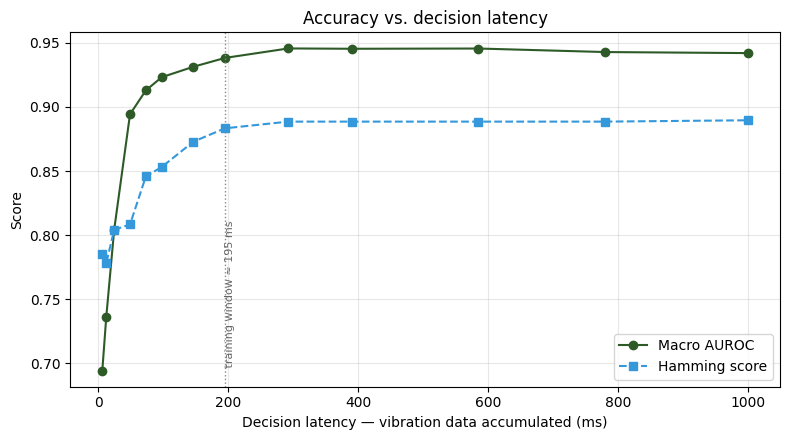

In [22]:
from fd_utils import sweep_decision_latency, plot_accuracy_vs_latency

latency_sweep = sweep_decision_latency(model_akida, X_test, y_test, timestep=TIMESTEP, in_akida=True)

print(f"{'chunks':>6} {'latency (ms)':>13} {'macro AUROC':>12} {'hamming':>9}")
for c, ms, au, ham in zip(latency_sweep['chunks'], latency_sweep['latency_ms'],
                          latency_sweep['auroc'], latency_sweep['hamming']):
    print(f"{c:>6} {ms:>13.1f} {au:>12.4f} {ham:>9.4f}")

plot_accuracy_vs_latency(latency_sweep, train_window_ms=MODEL_LENGTH / SAMPLE_RATE * 1000)

## Summary

This notebook demonstrated the complete pipeline for **bearing fault detection on Pico**:

1. **Loaded** 240 held-out test segments (~1-second benchmark) from UORED-VAFCLS (8 bearings, 42 kHz, multi-label)
2. **Built** a TENN SSM model (~17K parameters) and loaded trained weights
3. **Converted** to a stateful streaming model (256-sample chunks, 6.1 ms per frame)
4. **Quantized** to INT8 weights / INT8 activations / INT16 input
5. **Converted to Akida and mapped** the model onto the Pico FPGA as a single hardware sequence
6. **Measured** hardware performance: ~164 fps required; Pico sustains ~775 fps at 50 MHz (~4.7× the ~164 fps needed)
7. **Evaluated** float vs Akida (AUROC + per-label accuracy) — quantization leaves accuracy essentially unchanged
8. **Demonstrated** continuous streaming inference on a concatenated vibration stream, running on Pico
9. **Characterized** accuracy vs. decision latency to choose a prediction window

The full float → stateful → INT8 → Akida path runs end-to-end on hardware.